# Performance von Python mit NumPy und Vektoroperationen

- NumPy ist besonders nützlich, weil es viel schneller ist als Standard-Python-Listen für numerische Berechnungen.


Im folgenden Beispiel vergleichen wir die Zeit, die benötigt wird, um die Summe der Quadrate von 0 bis 9.999.999 zu berechnen
- einmal mit einer Python-Liste 
- einmal mit einem NumPy-Array.


In [1]:
import numpy as np
import time

start = time.time()
my_list = [x**2 for x in range(int(1e7))]
end = time.time()
print("Zeit für Liste:", end - start)

start = time.time()
my_array = np.arange(int(1e7))**2
end = time.time()
print("Zeit für NumPy-Array:", end - start)


Zeit für Liste: 1.4954321384429932
Zeit für NumPy-Array: 0.012539863586425781


Der Grund für die höhere Geschwindigkeit von NumPy liegt darin, dass NumPy-Arrays in C implementiert sind und Operationen auf ihnen in optimiertem maschinennahen Code ausgeführt werden, während Python-Listen in Python selbst implementiert sind und daher langsamer sind.
- `ndarray`-Daten liegen als zusammenhängende Blöcke im Speicher vor, was die Cache-Ausnutzung verbessert und die Leistung erhöht.
- NumPy nutzt Vektoroperationen, die auf mehreren Datenpunkten gleichzeitig arbeiten können, was die Effizienz weiter steigert und parallele Verarbeitung ermöglicht.

## Vermeidung von Python-Schleifen
- Python-Schleifen sind im Allgemeinen langsamer als Vektoroperationen mit NumPy.
- Versuchen Sie, Schleifen zu vermeiden, indem Sie stattdessen NumPy-Funktionen und -Operationen verwenden.

__Beispiel elementweise Operationen:__ Im folgenden Beispiel wollen wir alle Elemente des Vektors `vec` auf Null setzen, die entweder durch 3 oder durch 5 teilbar sind.

In [2]:
vec = np.arange(1e7)

# Mit Schleife
start = time.time()
for i,x in enumerate(vec):
    if x % 3 == 0 or x % 5 == 0:
        vec[i] = 0
end = time.time()
print("Zeit für Schleife:", end - start)

# Mit Vektoroperation
vec = np.arange(1e7)
start = time.time()
vec[(vec % 3 == 0) | (vec % 5 == 0)] = 0
end = time.time()
print("Zeit für Vektoroperation:", end - start)

Zeit für Schleife: 2.2064380645751953
Zeit für Vektoroperation: 0.41726183891296387


### Beispiel `np.sum()`
Die Methode `np.sum()` kann verwendet werden um die Summe aller Elemente in einem NumPy-Array zu berechnen.
- `np.sum(A, axis=k)` berechnet die Summe entlang der Achse `k` (0 für Spalten, 1 für Zeilen) und gibt ein Array mit den Summen zurück.
- Ohne Angabe von `axis` wird die Summe aller Elemente im Array berechnet und als Skalar zurückgegeben.

Im folgenden Beispiel erstellen wir eine zufällige Matrix $A\in \{-1,1\}^{n\times n}$ und berechnen die Summe aller Elemente in $A$ sowie die Summe jeder Spalte und jeder Zeile.

In [3]:
# erstellen eine kleinen zufälligen -1,1-Matrix
A = np.random.rand(5,5)
A[A < 0.5] = -1
A[A >= 0.5] = 1
print("Matrix A:\n", A)
# alternative kann man die choice-Methode verwenden
A = np.random.choice([-1, 1], size=(5,5))
print("Matrix A:\n", A)

print("Summe aller Elemente in A:", np.sum(A))
print("Summe jeder Spalte in A:", np.sum(A, axis=0))
print("Summe jeder Zeile in A:", np.sum(A, axis=1))

Matrix A:
 [[-1.  1.  1. -1. -1.]
 [ 1. -1.  1.  1.  1.]
 [ 1. -1. -1.  1.  1.]
 [-1.  1.  1.  1. -1.]
 [ 1.  1.  1. -1.  1.]]
Matrix A:
 [[-1  1 -1  1 -1]
 [ 1 -1  1  1 -1]
 [ 1  1 -1 -1  1]
 [ 1 -1  1 -1  1]
 [-1  1 -1  1  1]]
Summe aller Elemente in A: 3
Summe jeder Spalte in A: [ 1  1 -1  1  1]
Summe jeder Zeile in A: [-1  1  1  1  1]


Wenn wir $n$ nun sehr groß wählen, dann sehen wir, dass `np.sum` sehr viel schneller ist als eine Python-Schleife.

In [4]:
n = 10000
# erstellen eine großen zufälligen -1,1-Matrix  
A = np.random.choice([-1, 1], size=(n,n))
start = time.time()
total_sum = np.sum(A)
end = time.time()
print(f"Summe aller Elemente in A (n={n}):", total_sum)
print("Zeit für np.sum:", end - start)  

start = time.time()
total_sum = 0
for i in range(n):
    for j in range(n):
        total_sum += A[i,j]
end = time.time()
print(f"Summe aller Elemente in A (n={n}):", total_sum)
print("Zeit für Schleife:", end - start)


Summe aller Elemente in A (n=10000): 15150
Zeit für np.sum: 0.06076812744140625
Summe aller Elemente in A (n=10000): 15150
Zeit für Schleife: 14.8336341381073


### Weitere Operationen auf Arrays
- `np.mean(A, axis=k)` berechnet den Mittelwert entlang der Achse `k`.
- `np.std(A, axis=k)` berechnet die Standardabweichung entlang der Achse `k`.
- `np.min(A, axis=k)` und `np.max(A, axis=k)` finden das Minimum bzw. Maximum entlang der Achse `k`.
- `np.argmin(A, axis=k)` und `np.argmax(A, axis=k)` geben die Indizes des Minimums bzw. Maximums entlang der Achse `k` zurück.
- `np.sort(A, axis=k)` sortiert die Elemente entlang der Achse `k`.
- `np.unique(A)` gibt die eindeutigen Elemente im Array zurück.

Das NumPy Modul bietet viele weitere Funktionen für die Arbeit mit Arrays, die alle darauf ausgelegt sind, effizient und schnell zu sein. 
- Es lohnt sich, die Dokumentation zu durchsuchen https://numpy.org/doc/stable/
- Alternativ können Sie CoPilot fragen 
    - "Welche Funktionen bietet NumPy für die Arbeit mit Arrays?"
    - "How can I compute the the row-sum of a matrix in NumPy?"

## Initialisierung von Arrays (Aufwand)
- Die Erstellung eines NumPy-Arrays erfordert die Reservierung eines zusammenhängenden Speicherblocks
- Wenn das Array verlängert wird, muss möglicherweise ein neuer Speicherblock reserviert und die Daten kopiert werden, was zeitaufwändig sein kann.
- Um dies zu vermeiden, reserviert man bereits zu Beginn genügend Speicherplatz, z.B. durch `np.zeros((n,m))` oder `np.empty((n,m))` (falls die Längen `n` und `m` bekannt sind).

In [5]:
import numpy as np
import time
n = 2**16
start = time.time()
x = np.zeros((n,), dtype=int)
for i in range(n):
    x[i] = i
end = time.time()
print("Zeit mit Initialisierung ", end - start)

start = time.time()
x = np.zeros((1,), dtype=int)
for i in range(1,n):
    x = np.append(x,i)
end = time.time()
print("Zeit ohne Initialisierung", end - start)

start = time.time()
x = np.arange(n, dtype=int)
end = time.time()
print("Zeit mit arange", end - start)

start = time.time()
x = np.array(range(n), dtype=int)
end = time.time()
print("Zeit mit array und range", end - start)

Zeit mit Initialisierung  0.004262208938598633
Zeit ohne Initialisierung 0.6081938743591309
Zeit mit arange 0.00032901763916015625
Zeit mit array und range 0.0019659996032714844


## Effiziente Funktionsaufrufe
Ein Grundprinzip in Python lautet: __Funktionen sollten keine Nebeneffekte haben.__
- Das bedeutet, dass eine Funktion keine Variablen außerhalb ihres eigenen Gültigkeitsbereichs ändern sollte.
- __Problem__: Bei sehr großen Arrays kann das erstellen einer Kopie sehr aufwändig sein
- __Lösung__: Grundprinzip ignorieren aber Nebeneffekte genau dokumentieren

In [6]:
import numpy as np
import time
n = 10**8
def copy_vector(vec):
    # Create a copy of the vector to avoid modifying the original
    vec_copy = vec.copy()
    vec_copy[0] = -1  
    return vec_copy

def inplace_vector(vec):
    '''Sets the first element of the vector to -1 by modifying the original vector (inplace).'''
    vec[0] = -1  # Set even numbers to -1
    

# Original vector
large_vector = np.arange(n)

start = time.time()
x = copy_vector(large_vector)
end = time.time()
print("Zeit für Kopie:", end - start)
print("Originalvektor nach Kopie-Funktion (sollte unverändert sein):", large_vector[0])

start = time.time()
inplace_vector(large_vector)
end = time.time()
print("Zeit für Inplace:", end - start)
print("Originalvektor nach Inplace-Funktion (sollte verändert sein):", large_vector[0])

Zeit für Kopie: 0.1699810028076172
Originalvektor nach Kopie-Funktion (sollte unverändert sein): 0
Zeit für Inplace: 4.00543212890625e-05
Originalvektor nach Inplace-Funktion (sollte verändert sein): -1


## `out`-Parameter in `NumPy`
Viele NumPy-Funktionen bieten einen `out`-Parameter, der es ermöglicht, das Ergebnis einer Operation in einem bereits existierenden Array zu speichern, anstatt ein neues Array zu erstellen. Dies kann die Leistung verbessern, da es die Notwendigkeit reduziert, zusätzlichen Speicher zuzuweisen und Daten zu kopieren.



In [7]:
import numpy as np
import time
n = 10**7
x = np.random.rand(n)
y = np.random.rand(n)
res = np.zeros((n,))

# Using the out parameter to save the result in an existing array
start = time.time()
for _ in range(100):
    np.multiply(x, y, out=res)  # Element-wise multiplication, result stored in 'res'
    np.add(res, x, out=res)  # Element-wise addition, result stored in 'res'
end = time.time()
print("Zeit mit out-Parameter:", end - start)

# Without using the out parameter (creates a new array)
start = time.time()
for _ in range(100):
    result = x*y 
    result = result + x  # Element-wise multiplication, result stored in a new array
end = time.time()
print("Zeit ohne out-Parameter:", end - start)

Zeit mit out-Parameter: 1.0216848850250244
Zeit ohne out-Parameter: 2.085510015487671


## Beispiel: Die Fläche von Österreich berechnen

Eine wichtige Methode in der numerischen Mathematik ist die __Monte-Carlo-Methode__. Ein Anwendung der Methode ist die Berechnung von Flächeninhalten.
- Man umgibt die zu berechnende Fläche mit einem Rechteck, dessen Fläche leicht zu berechnen ist.
- Dann generiert man zufällige Punkte innerhalb dieses Rechtecks.
- Der Anteil der Punkte, die innerhalb der zu berechnenden Fläche liegen, entspricht dem Verhältnis der Flächeninhalte.

Wir erinnern uns an die Funktion die überprüft ob ein Punkt innerhalb eines Polygons liegt

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Funktion, die überprüft, ob ein Punkt innerhalb eines Polygons liegt
def inside_poly(poly, point):    
    x, y = point
    n = len(poly)
    counter = 0

    for i in range(n):
        x1, y1 = poly[i]
        x2, y2 = poly[(i + 1) % n]
        if ((y1 > y) != (y2 > y)) and (x < (x2 - x1) * (y - y1) / (y2 - y1) + x1):
            counter += 1

    return counter % 2 == 1

Der nächste Code-Block lädt die Eckpunkte eines Polygons das die Grenzen von Österreich approximiert und berechnet das kleinste umgebende Rechteck (Bounding Box).
Die Fläche der Bounding Box wird approximativ mit Werten aus einem Online Kartendienst berechnet (Länge x Breite).
- Die Eckpunkte des Polygons sind in der Datei `data/austria_vertices.npy` gespeichert.
- Die Datei wurde durch manuelles Nachzeichnen der Grenzen von Österreich in einem Online-Kartendienst erstellt

In [2]:
# Lade die Grenzen von Österreich
austria_vertices = np.load("data/austria_vertices.npy")
# Box um Österreich
bounding_box = np.array([np.min(austria_vertices[:,0]), np.min(austria_vertices[:,1]),
                         np.max(austria_vertices[:,0]), np.max(austria_vertices[:,1])])
box_area = 562 * 287  # ca. Fläche der Bounding Box in km²

Schließlich generieren wir zufällige Punkte innerhalb der Bounding Box und überprüfen, wie viele davon innerhalb des Polygons liegen. Daraus können wir den Flächeninhalt von Österreich abschätzen.

In [7]:
# Generiere zufällige Punkte innerhalb der Bounding Box
samples = 10000
random_points = np.random.rand(samples, 2)
random_points[:, 0] = random_points[:, 0] * (bounding_box[2] - bounding_box[0]) + bounding_box[0]
random_points[:, 1] = random_points[:, 1] * (bounding_box[3] - bounding_box[1]) + bounding_box[1]

# Überprüfe, ob die Punkte innerhalb oder außerhalb des Polygons liegen
points_inside = np.array([inside_poly(austria_vertices, point) for point in random_points])
print(f"Anteil der Punkte innerhalb von Österreich: {np.sum(points_inside==True)/samples:.2%}")
print(f"Geschätzte Fläche von Österreich: {np.sum(points_inside==True)/samples * box_area:.2f} (tatsächlich ca. 83883 km²)")

Anteil der Punkte innerhalb von Österreich: 52.48%
Geschätzte Fläche von Österreich: 84647.09 (tatsächlich ca. 83883 km²)


Letztlich visualisieren wir das Polygon, die Bounding Box und die zufällig generierten Punkte.

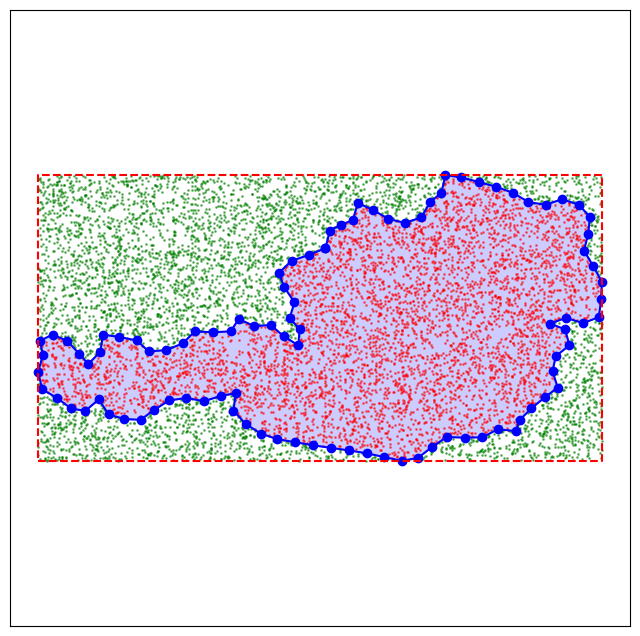

In [8]:
# Visualisierung der Berechnung
plt.figure(figsize=(8, 8))
plt.plot(austria_vertices[:, 0], austria_vertices[:, 1], 'b-', marker='o')
plt.fill(austria_vertices[:, 0], austria_vertices[:, 1], alpha=0.2, color='blue')
plt.plot([bounding_box[0], bounding_box[2], bounding_box[2], bounding_box[0], bounding_box[0]],
         [bounding_box[1], bounding_box[1], bounding_box[3], bounding_box[3], bounding_box[1]], 'r--')
plt.scatter(random_points[points_inside,0], random_points[points_inside,1], color='red', s=1, alpha=0.5)
plt.scatter(random_points[~points_inside,0], random_points[~points_inside,1], color='green', s=1, alpha=0.5)
plt.xticks([])
plt.yticks([])
plt.axis('equal')
plt.show()